# Actividad Redes

Hugo André Meza Fierros - A00841695

In [1]:
import pulp

## Flujo máximo

Un padre tiene cinco hijos adolescentes y cinco tareas para asignarles. La experiencia ha indicado que es contraproducente forzar a que los niños acepten determinadas tareas. Teniendo eso en cuenta, les pide a sus hijos hacer una lista de preferencias entre las cinco tareas, y resulta la siguiente tabla:

| Niño | Tarea preferida | 
| :----: | :----: | 
| Rif | 3, 4 o 5 | 
| Mai | 1 |
| Ben | 1 o 2 |
| Kim | 1, 2 o 5 |
| Ken | 2 |


El modesto objetivo del padre es terminar todas las tareas posibles y atender al mismo tiempo las preferencias de sus hijos. Determine la cantidad máxima de tareas que pueden terminarse y la asignación de tareas a hijos.

In [9]:
'''
I = {1, 2, ..., 5} <--- Niños
J = {1, 2, ..., 5} <--- Tareas

x_ij = {1 si el niño i hace la tarea j, 0 en otro caso}
'''
model = pulp.LpProblem("Asignación_Flujo_Maximo", pulp.LpMaximize)


hijos = ['Rif', 'Mai', 'Ben', 'Kim', 'Ken']
tareas = [1, 2, 3, 4, 5]

preferencias = {
    'Rif': [3, 4, 5], 
    'Mai': [1], 
    'Ben': [1, 2],
    'Kim': [1, 2, 5],
    'Ken': [2]
}

x = {}
for hijo in hijos:
    for tarea in preferencias[hijo]:
        x[(hijo, tarea)] = pulp.LpVariable(f"x_{hijo}_{tarea}", cat = 'Binary')

model += pulp.lpSum(x[(hijo, tarea)] for hijo in hijos for tarea in preferencias[hijo])

for hijo in hijos:
    model += pulp.lpSum(x[(hijo, tarea)] for tarea in preferencias[hijo]) <= 1 

for tarea in tareas:
    hijos_interesados = [h for h in hijos if tarea in preferencias[h]]
    if hijos_interesados:
        model += pulp.lpSum(x[(hijo, tarea)] for hijo in hijos_interesados) <= 1


model.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Estatus del modelo: {pulp.LpStatus[model.status]}")
print(f"Cantidad máxima de tareas que pueden terminarse: {int(pulp.value(model.objective))}\n")
print("Asignación óptima de tareas:")

for hijo in hijos:
    asignado = False
    for tarea in preferencias[hijo]:
        if pulp.value(x[(hijo, tarea)]) == 1:
            print(f"  - {hijo} realizará la Tarea {tarea}")
            asignado = True
    if not asignado:
        print(f"  - {hijo} no recibe ninguna tarea de su preferencia")

Estatus del modelo: Optimal
Cantidad máxima de tareas que pueden terminarse: 4

Asignación óptima de tareas:
  - Rif realizará la Tarea 3
  - Mai realizará la Tarea 1
  - Ben no recibe ninguna tarea de su preferencia
  - Kim realizará la Tarea 5
  - Ken realizará la Tarea 2


## Costo mínimo

Makonsel es una compañía integral que produce bienes y los vende en sus propias tiendas. Después de producidos los bienes se colocan en dos almacenes hasta que las tiendas los necesitan. Se usan camiones para transportar los bienes a los almacenes y luego a las tres tiendas.

Utilice una carga completa de camión como unidad; la siguiente tabla muestra la producción mensual de cada planta, su costo de transporte por carga enviada a cada almacén y la cantidad máxima que se puede enviar al mes a cada uno.

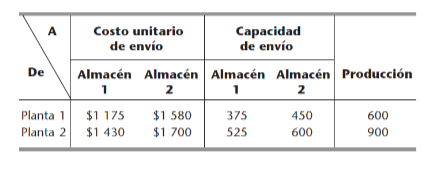

La siguiente tabla contiene la demanda mensual de cada tienda (T ), el costo de transporte por camión desde cada almacén y la cantidad máxima que se puede enviar al mes desde cada uno.

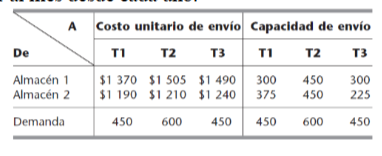

La administración desea determinar un plan de distribución —número de cargas enviadas al mes de cada planta a cada almacén y de cada uno de éstos a cada tienda— de modo que se minimice el costo total de transporte.

a) Trace una red que describa la red de distribución de la compañía. Identifique en ella los nodos fuente, de trasbordo y de demanda.

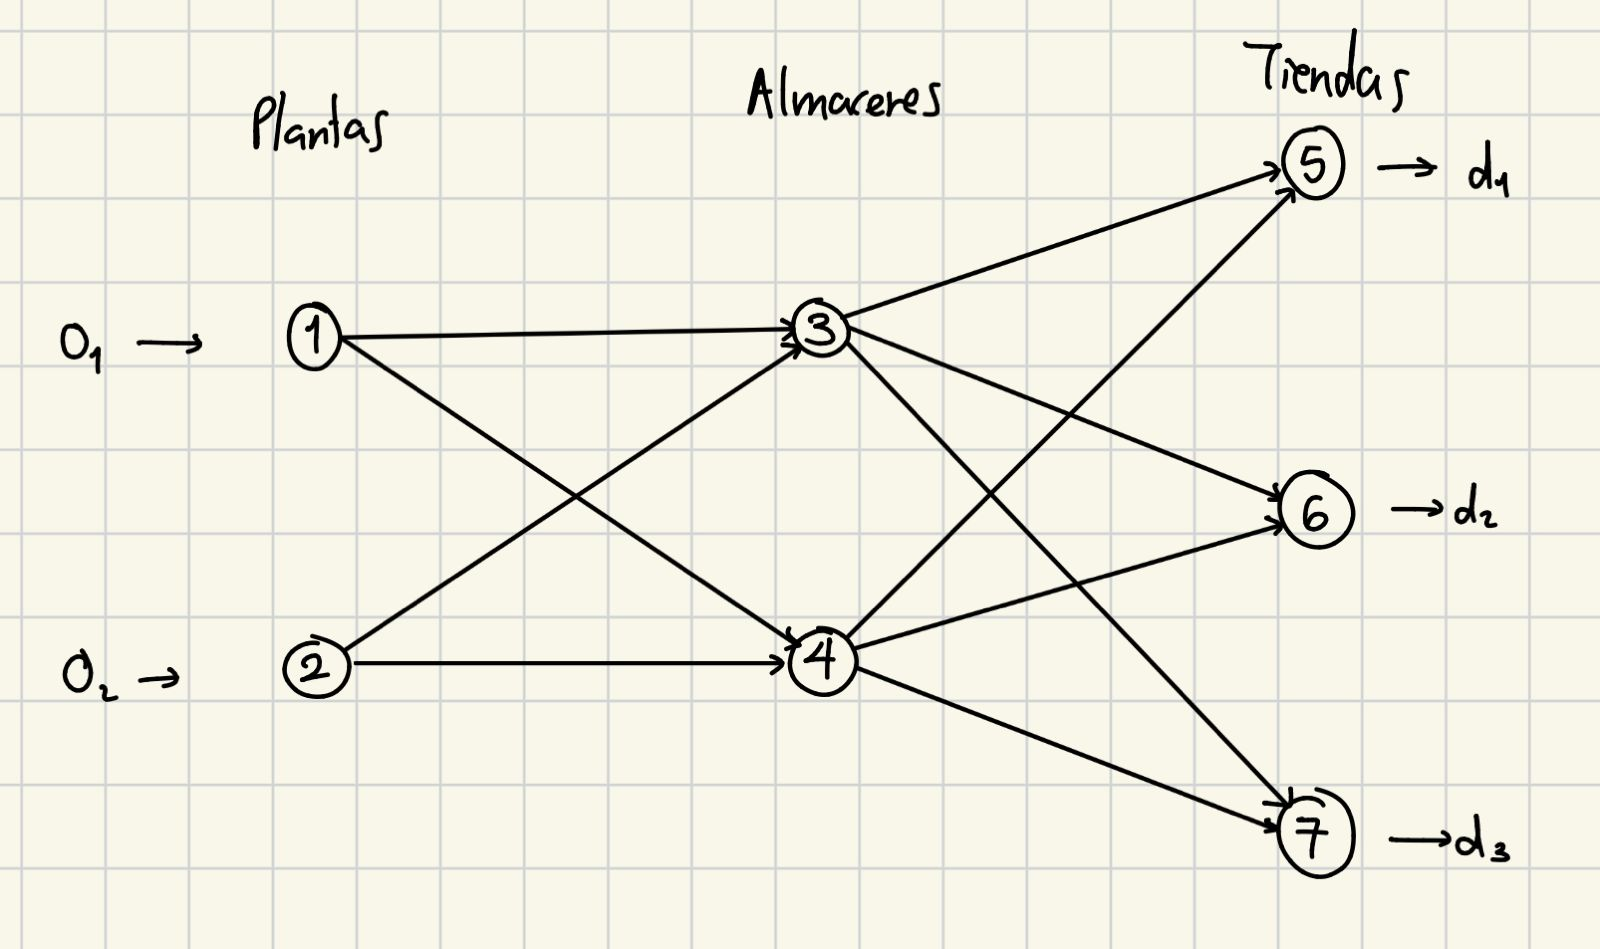


b) Formule este problema como uno de flujo de costo mínimo y coloque todos los datos necesarios.

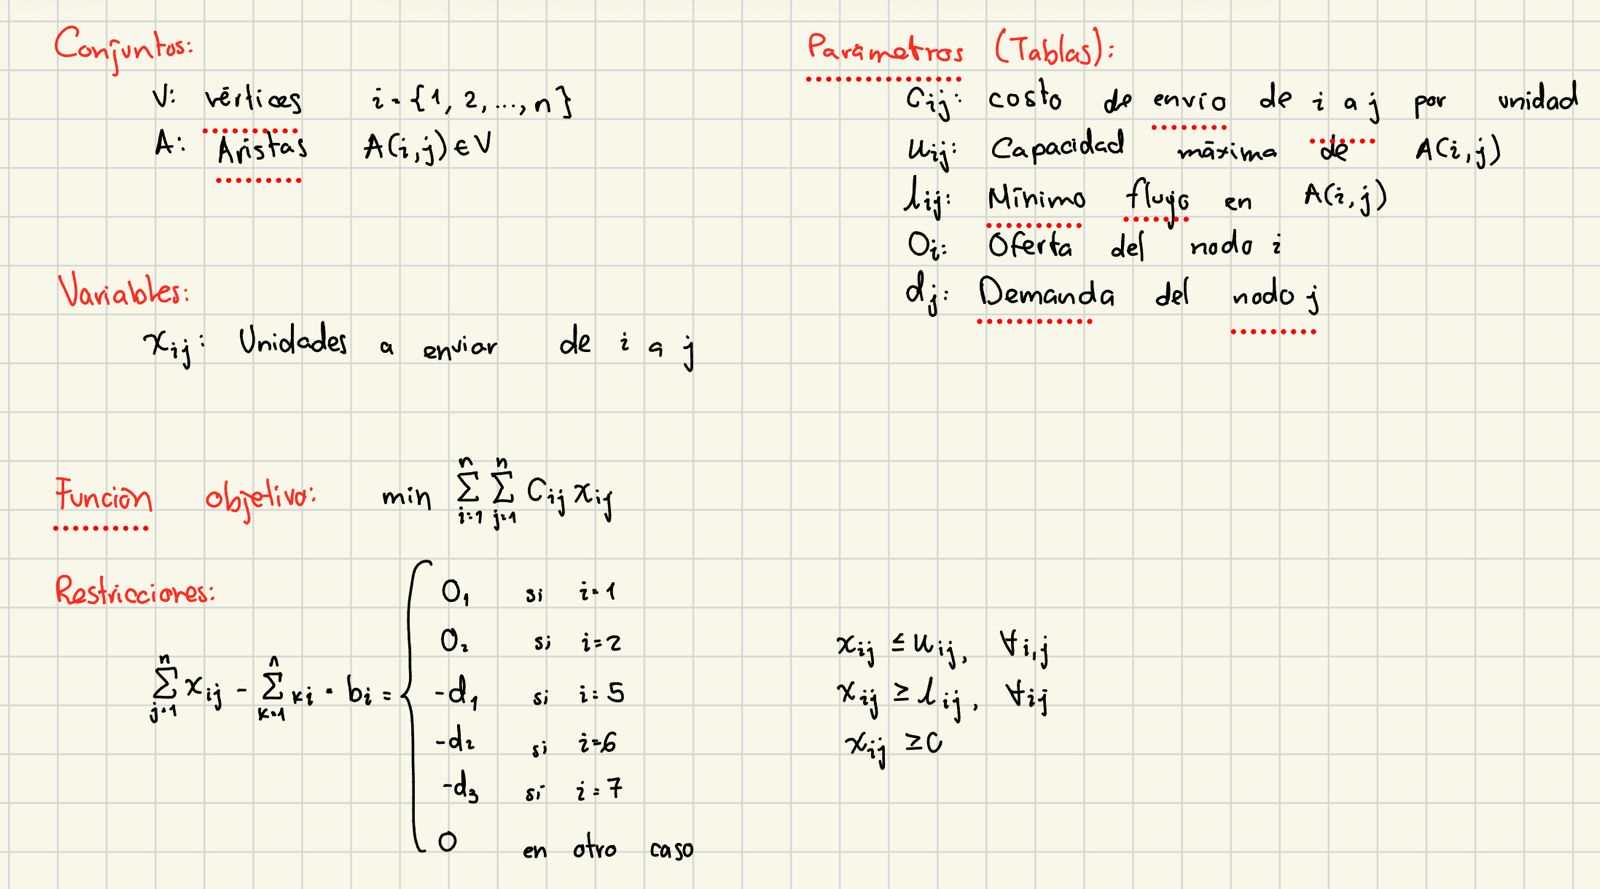

c) Formule y resuelva un modelo.

In [11]:
prob = pulp.LpProblem("Flujo_Costo_Minimo_Nodos", pulp.LpMinimize)

nodos = [1, 2, 3, 4, 5, 6, 7]

b = {
    1: 600,   # O1 (Planta 1)
    2: 900,   # O2 (Planta 2)
    3: 0,     # Almacén 1
    4: 0,     # Almacén 2
    5: -450,  # -d1 (Tienda 1)
    6: -600,  # -d2 (Tienda 2)
    7: -450   # -d3 (Tienda 3)
}

datos_arcos = {
    # De Plantas (1,2) a Almacenes (3,4)
    (1, 3): [1175, 375],
    (1, 4): [1580, 450],
    (2, 3): [1430, 525],
    (2, 4): [1700, 600],
    # De Almacenes (3,4) a Tiendas (5,6,7)
    (3, 5): [1370, 300],
    (3, 6): [1505, 450],
    (3, 7): [1490, 300],
    (4, 5): [1190, 375],
    (4, 6): [1210, 450],
    (4, 7): [1240, 225]
}

# Lista de todas las aristas (i,j) válidas
aristas = list(datos_arcos.keys())

x = pulp.LpVariable.dicts("Flujo", aristas, lowBound=0)

for i, j in aristas:
    x[(i, j)].upBound = datos_arcos[(i, j)][1]  # Límite superior = Capacidad


prob += pulp.lpSum([datos_arcos[(i, j)][0] * x[(i, j)] for (i, j) in aristas]), "Costo_Total"

for i in nodos:
    # Flujo que sale del nodo i
    flujo_saliente = pulp.lpSum([x[(i, j)] for j in nodos if (i, j) in aristas])
    
    # Flujo que entra al nodo i 
    flujo_entrante = pulp.lpSum([x[(k, i)] for k in nodos if (k, i) in aristas])
    
    # Restricción general
    prob += (flujo_saliente - flujo_entrante == b[i]), f"Balance_Nodo_{i}"

prob.solve()


print("-" * 30)
print(f"Estado: {pulp.LpStatus[prob.status]}")
print(f"Costo Mínimo Total: ${pulp.value(prob.objective):,.2f}")
print("-" * 30)
print("Plan de envíos (Nodos):")

for (i, j) in aristas:
    if x[(i, j)].varValue > 0:
        print(f"Nodo {i} -> Nodo {j}: {x[(i, j)].varValue} unidades (Cap. max: {datos_arcos[(i,j)][1]})")

------------------------------
Estado: Optimal
Costo Mínimo Total: $4,217,625.00
------------------------------
Plan de envíos (Nodos):
Nodo 1 -> Nodo 3: 375.0 unidades (Cap. max: 375)
Nodo 1 -> Nodo 4: 225.0 unidades (Cap. max: 450)
Nodo 2 -> Nodo 3: 375.0 unidades (Cap. max: 525)
Nodo 2 -> Nodo 4: 525.0 unidades (Cap. max: 600)
Nodo 3 -> Nodo 5: 300.0 unidades (Cap. max: 300)
Nodo 3 -> Nodo 6: 150.0 unidades (Cap. max: 450)
Nodo 3 -> Nodo 7: 300.0 unidades (Cap. max: 300)
Nodo 4 -> Nodo 5: 150.0 unidades (Cap. max: 375)
Nodo 4 -> Nodo 6: 450.0 unidades (Cap. max: 450)
Nodo 4 -> Nodo 7: 150.0 unidades (Cap. max: 225)
